In [2]:
import numpy as np
import matplotlib.pyplot as plt


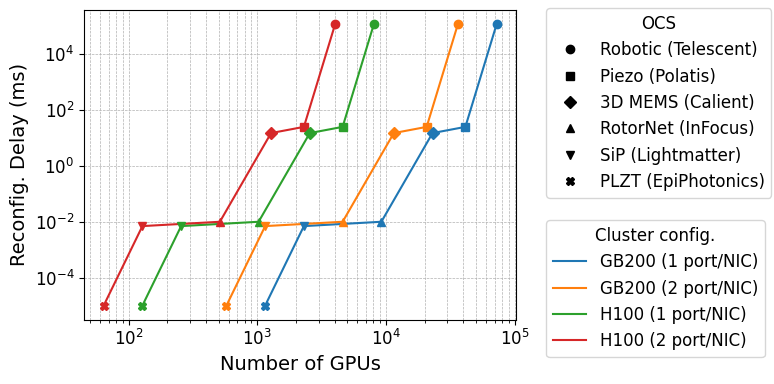

In [3]:

# Data
plt.rcParams.update({'font.size': 12})
technologies = [
    "Robotic (Telescent)",
    "Piezo (Polatis)",
    "3D MEMS (Calient)",
    # "2D MEMS (Google Palomar)",
    "RotorNet (InFocus)",
    "SiP (Lightmatter)",
    "PLZT (EpiPhotonics)"
]

port_counts = [
    1008, 
    576, 
    320, 
    # 136, 
    128, 
    32, 
    16
]
switching_speeds = [
    1000 * 60 * 2,  # 1 minute
    25,
    15,
    # None,  # Not reported
    0.01, 
    0.007,
    0.00001
]

# assuming duplex transceiver
num_gpu_gb200_1_port = [port_count * 72 for port_count in port_counts]
num_gpu_gb200_2_port = [port_count * 36 for port_count in port_counts]  # better flexibility
num_gpu_h100_1_port = [port_count * 8 for port_count in port_counts]    # H100 has 8 ports
num_gpu_h100_2_port = [port_count * 4 for port_count in port_counts]    # better flexibility

# Marker styles per technology
markers = ['o', 's', 'D', '^', 'v', 'X']
colors = ['C0', 'C1', 'C2', 'C3']  # for config lines

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

# Draw config lines once
ax.plot(num_gpu_gb200_1_port, switching_speeds, color=colors[0], label="GB200 (1 port/NIC)")
ax.plot(num_gpu_gb200_2_port, switching_speeds, color=colors[1], label="GB200 (2 port/NIC)")
ax.plot(num_gpu_h100_1_port, switching_speeds, color=colors[2], label="H100 (1 port/NIC)")
ax.plot(num_gpu_h100_2_port, switching_speeds, color=colors[3], label="H100 (2 port/NIC)")

# Plot tech markers with labels
for i, tech in enumerate(technologies):
    marker = markers[i]
    y = switching_speeds[i]

    # Plot markers for each config
    ax.plot(num_gpu_gb200_1_port[i], y, marker=marker, color=colors[0], linestyle='None')
    ax.plot(num_gpu_gb200_2_port[i], y, marker=marker, color=colors[1], linestyle='None')
    ax.plot(num_gpu_h100_1_port[i], y, marker=marker, color=colors[2], linestyle='None')
    ax.plot(num_gpu_h100_2_port[i], y, marker=marker, color=colors[3], linestyle='None')

    # Annotate tech name once (near one config point)
    # ax.annotate(tech, (num_gpu_gb200_1_port[i], y), xytext=(5, 0), textcoords='offset points', fontsize=10)

# Legends
tech_handles = [plt.Line2D([], [], marker=markers[i], linestyle='None', label=technologies[i], color='black') for i in range(len(technologies))]
config_handles = [plt.Line2D([], [], color=colors[i], label=label) for i, label in enumerate([
    "GB200 (1 port/NIC)", "GB200 (2 port/NIC)", "H100 (1 port/NIC)", "H100 (2 port/NIC)"
])]

first_legend = ax.legend(handles=tech_handles, title="OCS", loc='center left', bbox_to_anchor=(1.05, 0.7))
second_legend = ax.legend(handles=config_handles, title="Cluster config.", loc='center left', bbox_to_anchor=(1.05, 0.1))
ax.add_artist(first_legend)

# Axes and formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Number of GPUs", fontsize=14)
ax.set_ylabel("Reconfig. Delay (ms)", fontsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
fig.savefig("scalability_plot.pdf", format="pdf")


Fat-tree: k=16, num_switch_fat_tree=320, num_switch_ports_fat_tree=5120
Rail-optimized: k=23, num_switch_rail_optimized=220, num_switch_ports_rail_optimized=5060
Cost saving: 3.32x for Opus over Rail-optimized
Power saving: 23.59x for Opus over Rail-optimized

 !!Total servers: 128
Fat-tree: Cost = $4329456.00, Power = 263360.00 W
Rail-optimized: Cost = $4281348.19, Power = 260393.75 W
Opus: Cost = $1289216.00, Power = 11040.00 W
-----------------------------------
Fat-tree: k=20, num_switch_fat_tree=500, num_switch_ports_fat_tree=10000
Rail-optimized: k=32, num_switch_rail_optimized=320, num_switch_ports_rail_optimized=10240
Cost saving: 3.36x for Opus over Rail-optimized
Power saving: 23.86x for Opus over Rail-optimized

 !!Total servers: 256
Fat-tree: Cost = $8466480.75, Power = 514855.00 W
Rail-optimized: Cost = $8658912.00, Power = 526720.00 W
Opus: Cost = $2578432.00, Power = 22080.00 W
-----------------------------------
Fat-tree: k=25, num_switch_fat_tree=781, num_switch_ports_

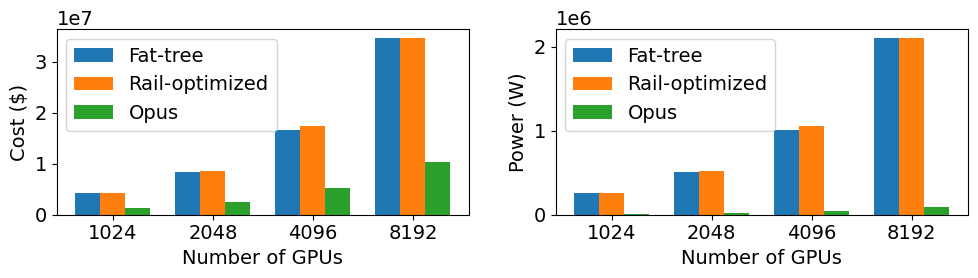

In [9]:
from matplotlib.ticker import ScalarFormatter
plt.rcParams.update({'font.size': 14})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# we pick polatis, h100, 128 servers, 400G, 1port per NIC, plot the energy consumption of fat-tree, rail-optimized topology, and Opus

transceiver_power = 10 #https://www.fs.com/products/110530.html?attribute=94270&id=4477813
switch_port_power = 2524/64 #https://www.fs.com/products/149853.html?now_cid=3255
ocs_port_power = 75/192 # polatis 6000N

transceiver_cost = 219 #https://www.fs.com/products/110530.html?attribute=94270&id=4477813

switch_port_cost_fat_tree = 37299/64 # 16 * 16 / 2 port, https://www.fs.com/products/149853.html?now_cid=3255
switch_port_cost_rail_optimized = 37299/64 # 8 * 8 / 2 port 

ocs_port_cost = 520

topologies = ['Fat-tree', 'Rail-optimized', 'Opus']

def get_cost_energy(total_server=128, num_gpu_per_server=8):

    total_gpu = total_server * num_gpu_per_server
    num_gpu_ports = total_server * num_gpu_per_server

    # Fat-tree
    k = int((total_gpu * 4) ** (1/3) + 0.5)
    radix = k

    num_switch_fat_tree = k ** 2 + k ** 2 // 4
    num_switch_ports_fat_tree = radix * num_switch_fat_tree
    print(f"Fat-tree: k={k}, num_switch_fat_tree={num_switch_fat_tree}, num_switch_ports_fat_tree={num_switch_ports_fat_tree}")

    # Rail-optimized
    # k = int((total_server * 4) ** (1/3) + 0.5)
    # radix = k
    # num_switch_fat_tree_per_rail = k ** 2
    # num_switch_spine = total_server # non-blocking

    # num_switch_rail_optimized = num_switch_fat_tree_per_rail * num_gpu_per_server + num_switch_spine
    # num_switch_ports_rail_optimized = radix * num_switch_fat_tree_per_rail * num_gpu_per_server + num_switch_spine * num_gpu_per_server
    k = int((total_server * 4) ** 0.5 + 0.5)
    num_switch_fat_tree_per_rail = total_server // (k // 2) * 2
    radix = k
    num_switch_spine = num_gpu_per_server * total_server // k
    num_switch_rail_optimized = num_switch_fat_tree_per_rail * num_gpu_per_server + num_switch_spine
    num_switch_ports_rail_optimized = radix * (num_switch_fat_tree_per_rail * num_gpu_per_server + num_switch_spine)
    print(f"Rail-optimized: k={k}, num_switch_rail_optimized={num_switch_rail_optimized}, num_switch_ports_rail_optimized={num_switch_ports_rail_optimized}")

    # opus
    num_ocs_opus = num_gpu_per_server
    radix = total_server * 2
    num_ocs_ports_opus = radix * num_ocs_opus


    # Cost
    total_cost_fat_tree = switch_port_cost_fat_tree * num_switch_ports_fat_tree + transceiver_cost * (num_gpu_ports + num_switch_ports_fat_tree)
    total_cost_rail_optimized = switch_port_cost_rail_optimized * num_switch_ports_rail_optimized + transceiver_cost * (num_gpu_ports + num_switch_ports_rail_optimized)
    total_cost_opus = ocs_port_cost * num_ocs_ports_opus + transceiver_cost * num_gpu_ports

    # Power
    total_power_fat_tree = switch_port_power * num_switch_ports_fat_tree + transceiver_power * (num_gpu_ports + num_switch_ports_fat_tree)
    total_power_rail_optimized = switch_port_power * num_switch_ports_rail_optimized + transceiver_power * (num_gpu_ports + num_switch_ports_rail_optimized)
    total_power_opus = ocs_port_power * num_ocs_ports_opus + transceiver_power * num_gpu_ports



    return [(total_cost_fat_tree, total_cost_rail_optimized, total_cost_opus),
            (total_power_fat_tree, total_power_rail_optimized, total_power_opus)]

num_servers = [128, 256, 512, 1024]
num_gpu_per_server = 8

# Collect cost and power data for each topology across different server counts
costs_data = []
powers_data = []

for total_server in num_servers:
    costs, powers = get_cost_energy(total_server=total_server, num_gpu_per_server=num_gpu_per_server)
    costs_data.append(costs)
    powers_data.append(powers)
    print(f"Cost saving: {costs[1] / costs[2]:.2f}x for Opus over Rail-optimized")
    print(f"Power saving: {powers[1] / powers[2]:.2f}x for Opus over Rail-optimized")

    print(f"\n !!Total servers: {total_server}")
    for i, topology in enumerate(topologies):
        print(f"{topology}: Cost = ${costs[i]:.2f}, Power = {powers[i]:.2f} W")
    print("-----------------------------------")

# Convert data to arrays for easier plotting
costs_data = np.array(costs_data)
powers_data = np.array(powers_data)

num_gpus = np.array(num_servers) * num_gpu_per_server

# Combine cost and power comparison plots horizontally
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Cost comparison bar plot
bar_width = 0.25
x_positions = np.arange(len(num_gpus))

for i, topology in enumerate(topologies):
    ax1.bar(x_positions + i * bar_width, costs_data[:, i], bar_width, label=topology)

ax1.set_xlabel('Number of GPUs')
ax1.set_ylabel('Cost ($)')
ax1.set_xticks(x_positions + bar_width)
ax1.set_xticklabels(num_gpus)
ax1.legend()

# Power comparison bar plot
for i, topology in enumerate(topologies):
    ax2.bar(x_positions + i * bar_width, powers_data[:, i], bar_width, label=topology)

ax2.set_xlabel('Number of GPUs')
ax2.set_ylabel('Power (W)')
ax2.set_xticks(x_positions + bar_width)
ax2.set_xticklabels(num_gpus)
ax2.legend()

plt.tight_layout()
plt.show()
# Save the figure to a PDF file
fig.savefig("cost_energy_plots.pdf", format="pdf")


